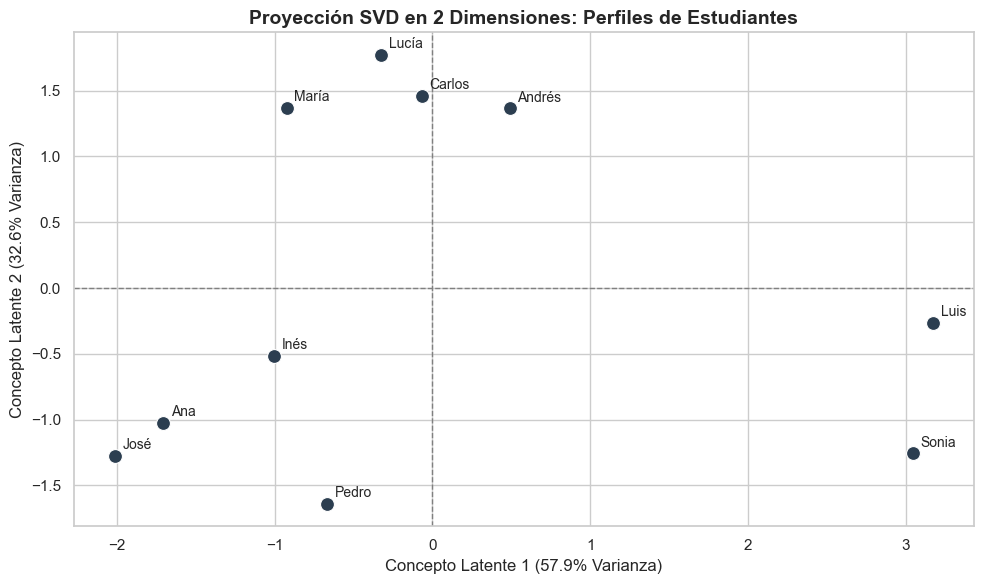

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD

# Configuración visual ejecutiva
sns.set_theme(style="whitegrid", palette="muted")

# 1. Cargar los datos de la rúbrica
data = {
    'Estudiante': ['Lucía', 'Pedro', 'Inés', 'Luis', 'Andrés', 'Ana', 'Carlos', 'José', 'Sonia', 'María'],
    'Matemáticas': [7.0, 7.5, 7.6, 5.0, 6.0, 7.8, 6.3, 7.9, 6.0, 6.8],
    'Ciencias': [6.5, 9.4, 9.2, 6.5, 6.0, 9.6, 6.4, 9.7, 6.0, 7.2],
    'Español': [9.2, 7.3, 8.0, 6.5, 7.8, 7.7, 8.2, 7.5, 6.5, 8.7],
    'Historia': [8.6, 7.0, 8.0, 7.0, 8.9, 8.0, 9.0, 8.0, 5.5, 9.0],
    'EdFísica': [8.0, 7.0, 7.5, 9.0, 7.3, 6.5, 7.2, 6.0, 8.7, 7.0]
}
df = pd.DataFrame(data).set_index('Estudiante')

# 2. Estandarización de los datos
scaler = StandardScaler()
A_scaled = scaler.fit_transform(df)

# 3. Aplicar SVD para 2 dimensiones
svd_2d = TruncatedSVD(n_components=2, random_state=42)
T_2d = svd_2d.fit_transform(A_scaled)

# Crear DataFrame para el reporte 2D
df_2d = pd.DataFrame(T_2d, columns=['Componente_1', 'Componente_2'], index=df.index)

# 4. Visualización 2D Ejecutiva
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(x='Componente_1', y='Componente_2', data=df_2d, s=100, color='#2c3e50')

# Agregar etiquetas para cada estudiante (CORREGIDO USANDO .loc)
for txt in df_2d.index:
    ax.annotate(txt, (df_2d.loc[txt, 'Componente_1'] + 0.05, df_2d.loc[txt, 'Componente_2'] + 0.05), fontsize=10)

plt.title('Proyección SVD en 2 Dimensiones: Perfiles de Estudiantes', fontsize=14, fontweight='bold')
plt.xlabel(f'Concepto Latente 1 ({svd_2d.explained_variance_ratio_[0]:.1%} Varianza)', fontsize=12)
plt.ylabel(f'Concepto Latente 2 ({svd_2d.explained_variance_ratio_[1]:.1%} Varianza)', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

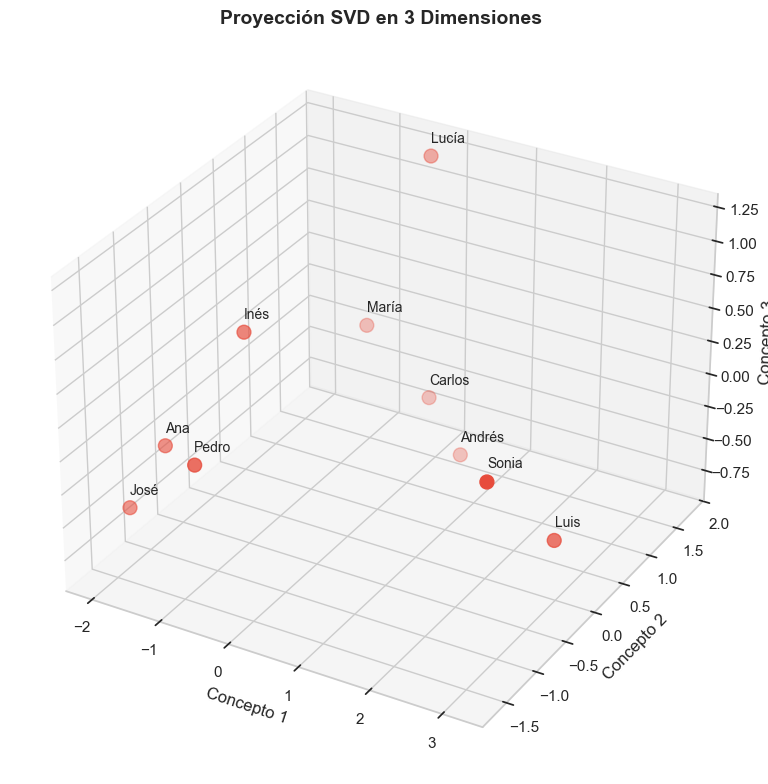

In [4]:
# 1. Aplicar SVD para 3 dimensiones
svd_3d = TruncatedSVD(n_components=3, random_state=42)
T_3d = svd_3d.fit_transform(A_scaled)

df_3d = pd.DataFrame(T_3d, columns=['C_1', 'C_2', 'C_3'], index=df.index)

# 2. Visualización 3D Ejecutiva
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficar puntos
ax.scatter(df_3d['C_1'], df_3d['C_2'], df_3d['C_3'], s=100, color='#e74c3c')

# Agregar etiquetas 3D (CORREGIDO USANDO .loc)
for txt in df_3d.index:
    ax.text(df_3d.loc[txt, 'C_1'], df_3d.loc[txt, 'C_2'], df_3d.loc[txt, 'C_3'] + 0.1, txt, fontsize=10)

ax.set_title('Proyección SVD en 3 Dimensiones', fontsize=14, fontweight='bold')
ax.set_xlabel('Concepto 1')
ax.set_ylabel('Concepto 2')
ax.set_zlabel('Concepto 3')
plt.tight_layout()
plt.show()